
## 4. Reducción de dimensionalidad — `comprar_alquilar.csv`
### Algoritmo: PCA (Análisis de Componentes Principales)

**Justificación del algoritmo:** `comprar_alquilar.csv` contiene 9 variables numéricas (ingresos, gastos,
ahorros, vivienda, estado civil, hijos, trabajo) que describen la situación financiera de un hogar, junto con
una etiqueta binaria (`comprar`: 1 si compra vivienda, 0 si alquila). Usar las 9 variables sin reducción
expone al model *Análisis no supervisado*  llama **la
maldición de la dimensionalidad**: *"a partir de cierto punto, el rendimiento del modelo disminuirá con el
creciente número de elementos  esta disminución provoca un sobreajuste"*. Se eligió **PCA** porque:
- Es el algoritmo de reducción de dimensionalidad practicado en los notebooks de clase *PCA Wine* y
  *Algoritmo PCA Reducción de dimensionalidad arrestos*, y corresponde a la técnica de **extracción de
  variables** vista en clase: *la formación de nuevas variables a partir de las antiguas
   PCA es el ejemplo de uno de estos métodos*.
- Permite comprimir las 9 variables originales en un número menor de componentes que conservan la mayor
  parte de la varianza (información) del conjunto de datos, facilitando la visualización y el posible uso
  posterior en otros modelos.
- Permite comparar el efecto de escalar o no escalar los datos antes de aplicar la técnica (tal como se
  ejemplifica en el notebook *PCA Wine*), ya que las variables tienen escalas muy distintas (ingresos en
  miles vs. número de hijos).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

%matplotlib inline
sns.set_style('whitegrid')


### Paso 1. Carga y exploración de los datos

In [2]:
DATA_DIR = os.path.join('..', '..', 'Conjunto de datos para 2a. evaluación')
datos = pd.read_csv(os.path.join(DATA_DIR, 'comprar_alquilar.csv'))
datos.head()


,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo,comprar
0,6000,1000,0,600,50000,400000,0,2,2,1
1,6745,944,123,429,43240,636897,1,3,6,0
2,6455,1033,98,795,57463,321779,2,1,8,1
3,7098,1278,15,254,54506,660933,0,0,3,0
4,6167,863,223,520,41512,348932,0,0,3,1


In [3]:
datos.describe()


,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo,comprar
count,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000
mean,4958.995050,971.584158,211.742574,515.425743,38749.668317,373349.638614,1.024752,1.232673,4.490099,0.331683
std,1682.862556,272.106351,124.940754,168.103075,17365.231870,136371.525622,0.837184,1.367833,2.535794,0.471988
min,2008.000000,384.000000,0.000000,201.000000,10319.000000,176553.000000,0.000000,0.000000,0.000000,0.000000
25%,3513.750000,766.750000,99.000000,383.250000,24964.250000,274810.000000,0.000000,0.000000,2.000000,0.000000
50%,4947.500000,968.000000,208.500000,522.500000,38523.000000,340783.500000,1.000000,1.000000,5.000000,0.000000
75%,6374.500000,1165.250000,318.750000,656.750000,52150.750000,444482.000000,2.000000,2.000000,7.000000,1.000000
max,7984.000000,1585.000000,448.000000,828.000000,69934.000000,669540.000000,2.000000,4.000000,8.000000,1.000000


comprar
0    135
1     67
Name: count, dtype: int64


C:\Users\Yosue\AppData\Local\Temp\ipykernel_18584\3937669331.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='comprar', data=datos, palette=['#C44E52', '#55A868'])


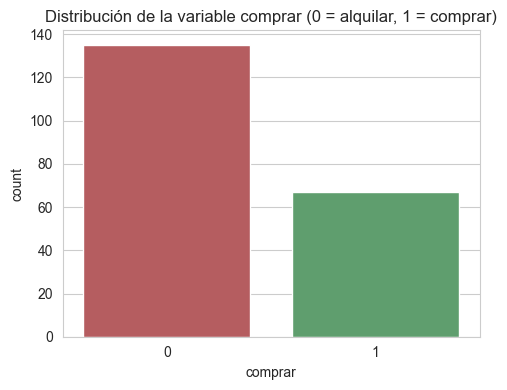

In [4]:
print(datos['comprar'].value_counts())
plt.figure(figsize=(5,4))
sns.countplot(x='comprar', data=datos, palette=['#C44E52', '#55A868'])
plt.title('Distribución de la variable comprar (0 = alquilar, 1 = comprar)')
plt.tight_layout()
plt.savefig('grafica_distribucion_comprar.png', dpi=120)
plt.show()


### Paso 2. Separación de variables

In [5]:
X = datos.drop(columns=['comprar']).values
y = datos['comprar'].values
columnas = datos.drop(columns=['comprar']).columns
print(X.shape, y.shape)


(202, 9) (202,)


### Paso 3. PCA sin escalamiento de datos

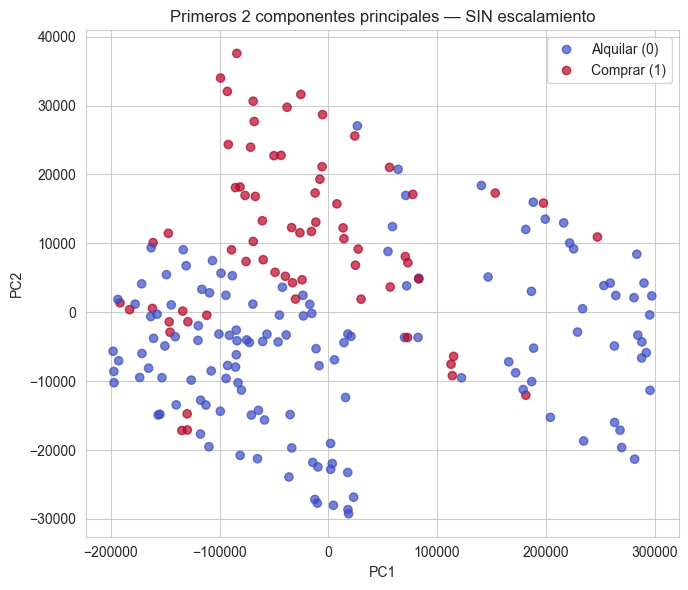

In [6]:
pca_sin_escalar = PCA()
X_pca_sin_escalar = pca_sin_escalar.fit_transform(X)

plt.figure(figsize=(7, 6))
plot1 = plt.scatter(X_pca_sin_escalar[:, 0], X_pca_sin_escalar[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.legend(handles=plot1.legend_elements()[0], labels=['Alquilar (0)', 'Comprar (1)'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Primeros 2 componentes principales — SIN escalamiento')
plt.tight_layout()
plt.savefig('grafica_pca_sin_escalar.png', dpi=120)
plt.show()


### Paso 4. PCA con escalamiento de datos (StandardScaler)

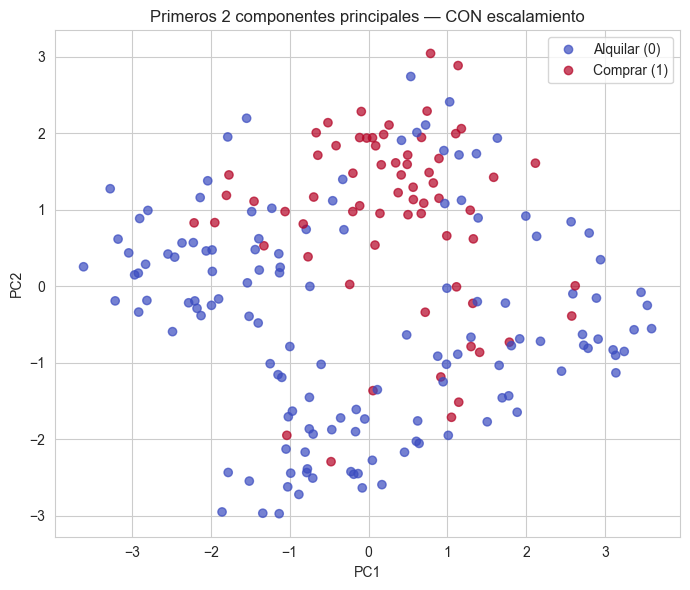

In [7]:
pipe = Pipeline([('escalador', StandardScaler()), ('pca', PCA())])
X_pca_escalado = pipe.fit_transform(X)

plt.figure(figsize=(7, 6))
plot2 = plt.scatter(X_pca_escalado[:, 0], X_pca_escalado[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.legend(handles=plot2.legend_elements()[0], labels=['Alquilar (0)', 'Comprar (1)'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Primeros 2 componentes principales — CON escalamiento')
plt.tight_layout()
plt.savefig('grafica_pca_con_escalar.png', dpi=120)
plt.show()


### Paso 5. Comparación lado a lado — con y sin escalamiento

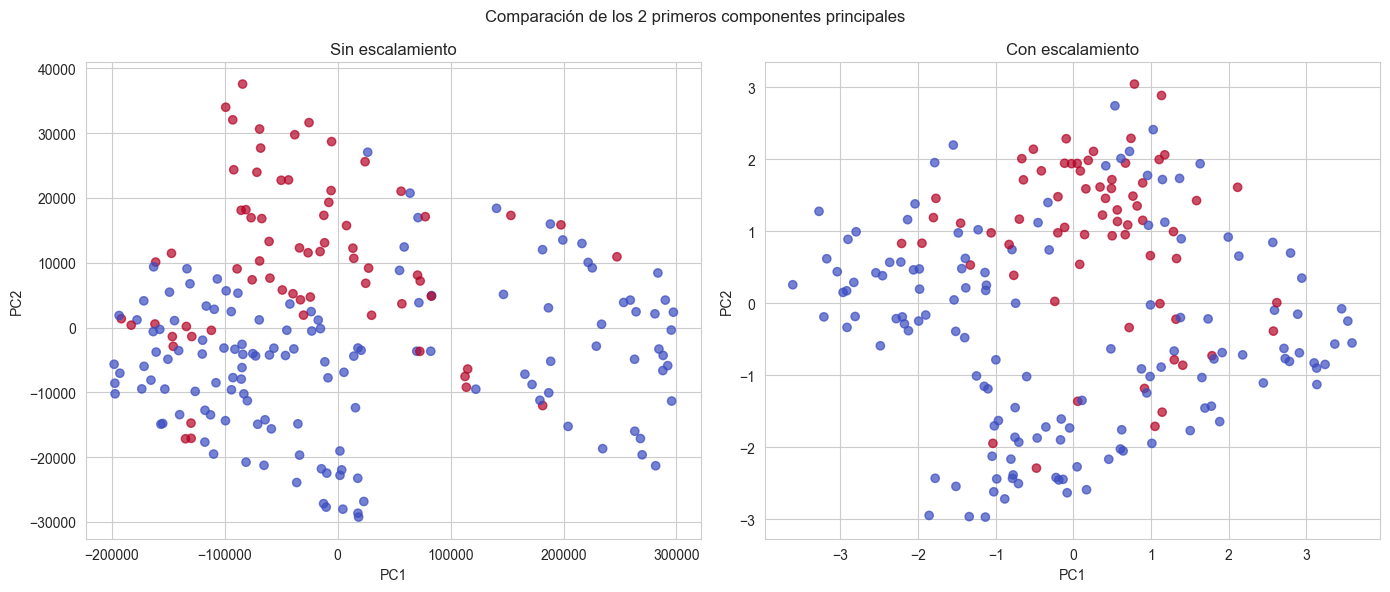

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_pca_sin_escalar[:, 0], X_pca_sin_escalar[:, 1], c=y, cmap='coolwarm', alpha=0.7)
axes[0].set_title('Sin escalamiento')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

axes[1].scatter(X_pca_escalado[:, 0], X_pca_escalado[:, 1], c=y, cmap='coolwarm', alpha=0.7)
axes[1].set_title('Con escalamiento')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.suptitle('Comparación de los 2 primeros componentes principales')
plt.tight_layout()
plt.savefig('grafica_pca_comparacion.png', dpi=120)
plt.show()


**Interpretación:** Sin escalar, la variable `vivienda` e `ingresos` (con valores mucho más grandes que el
resto) dominan por completo el primer componente, opacando la contribución de variables como `hijos` o
`estado_civil`. Al escalar los datos, todas las variables aportan de forma comparable al PCA y la separación
entre las clases `comprar`/`alquilar` en el plano PC1-PC2 se aprecia de forma más clara y balanceada. Por
ello, **se utiliza el PCA con escalamiento como versión final del modelo**.

### Paso 6. Selección del número de componentes (reducción de dimensionalidad)

Varianza explicada por componente: [0.299 0.233 0.117 0.107 0.096 0.056 0.041 0.03  0.02 ]
Varianza acumulada: [0.299 0.532 0.649 0.756 0.852 0.909 0.95  0.98  1.   ]


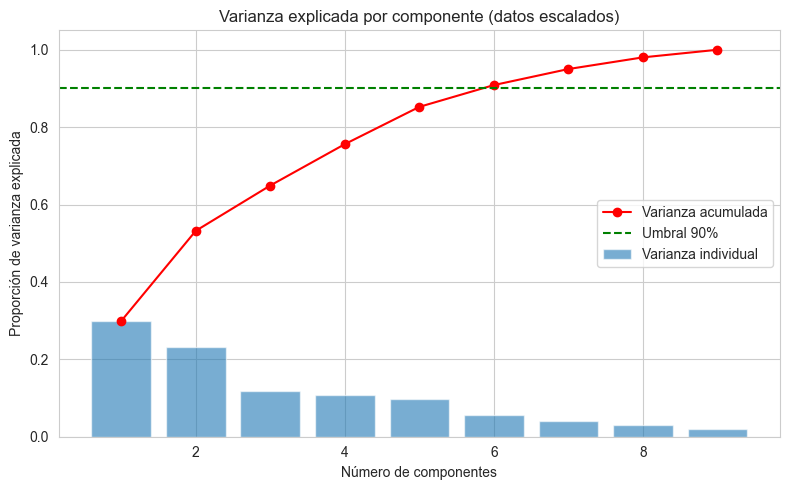

In [9]:
pca_final = pipe.named_steps['pca']
varianza_explicada = pca_final.explained_variance_ratio_
varianza_acumulada = varianza_explicada.cumsum()

print('Varianza explicada por componente:', np.round(varianza_explicada, 3))
print('Varianza acumulada:', np.round(varianza_acumulada, 3))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(range(1, len(varianza_explicada) + 1), varianza_explicada, alpha=0.6, label='Varianza individual')
ax.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', color='red',
        label='Varianza acumulada')
ax.axhline(y=0.90, color='green', linestyle='--', label='Umbral 90%')
ax.set_xlabel('Número de componentes')
ax.set_ylabel('Proporción de varianza explicada')
ax.set_title('Varianza explicada por componente (datos escalados)')
ax.legend()
plt.tight_layout()
plt.savefig('grafica_varianza_explicada.png', dpi=120)
plt.show()


In [10]:
N_COMPONENTES = int(np.argmax(varianza_acumulada >= 0.90) + 1)
print(f'Número de componentes elegido: {N_COMPONENTES}')
print(f'Varianza acumulada con {N_COMPONENTES} componentes: {varianza_acumulada[N_COMPONENTES-1]:.3f}')

pca_reducido = PCA(n_components=N_COMPONENTES)
X_reducido = pca_reducido.fit_transform(StandardScaler().fit_transform(X))
X_reducido_df = pd.DataFrame(X_reducido, columns=[f'PC{i+1}' for i in range(N_COMPONENTES)])
X_reducido_df.head()


Número de componentes elegido: 6
Varianza acumulada con 6 componentes: 0.909


,PC1,PC2,PC3,PC4,PC5,PC6
0,1.321915,-0.222950,1.599863,-0.885014,0.646617,-0.700208
1,1.147878,1.716967,0.395722,-0.447960,-0.687805,-0.231969
2,0.090369,1.836066,1.359382,0.337505,0.742387,0.593030
3,3.455898,-0.078279,-0.202382,-1.573584,-0.068551,-0.051945
4,0.916933,-1.184676,0.190036,0.117804,-0.147753,-0.619750


**Justificación del número de componentes elegido:** Se seleccionó el menor número de componentes
principales que en conjunto explican al menos el **90% de la varianza total** de los datos (línea verde
punteada en la gráfica). Esto permite reducir la dimensionalidad del conjunto de datos (de 9 variables
originales a un número menor de componentes) conservando la mayor parte de la información relevante para
diferenciar entre los hogares que compran y los que alquilan.

## Conclusión / Interpretación final
El escalamiento de los datos es indispensable ya que variables como `vivienda` e `ingresos` tienen magnitudes
mucho mayores que variables como `hijos` o `estado_civil`. El PCA con datos escalados y el número de
componentes elegido conserva la mayor parte de la información original reduciendo la complejidad del
conjunto de datos.

**Enlace al repositorio con el modelo:** https://github.com/YosueCh/2a.-Evaluaci-n-Extracci-n-de-conocimiento-en-bases-de-datos.git
